# 프로젝트 : 이송 예측하기

목차
1. 데이터셋 확인  
1.1 라이브러리, 데이터 불러오기  
1.2 결측치 확인  
1.3 Target label 확인, ID 삭제  
2. Exploratory data analysis   
2.1 HomePlanet  
2.2 CryoSleep  
2.3 Destination  
2.4 Age  
2.5 VIP  
2.7 소비패턴 분석  
2.8 Cabin  
4. Feature engineering
3.1 Fill Null data
3.1.1 Fill Null in Age using title  
3.1.2 Fill Null in Embarked
3.2 Change Age (continuous to categorical)
3.3 Change Initial, Embarked and Sex (string to numerical)
3.4 One-hot encoding on Initial and Embarked
3.5 Drop columns
5. Building machine learning model and prediction using the trained model
4.1 Preparation - Split dataset into train, valid and test set
4.2 Model generation and prediction
4.3 Feature importance
6. Conclusion

## 1. 데이터셋 확인

### 1.1 라이브러리, 데이터 불러오기

In [283]:
import numpy as np         ## 라이브러리 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


#ignore warnings
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

1. PassengerId- 각 승객에게는 고유 ID가 부여됩니다. 각 ID는 <그룹 번호> 형식으로 되어 있으며, < gggg_pp그룹 번호 gggg>는 승객이 속한 그룹을 나타내고 < pp그룹 내 번호>는 그룹 내 승객의 순번입니다. 그룹 구성원은 대개 가족이지만 항상 그런 것은 아닙니다.
2. HomePlanet- 승객이 출발한 행성, 일반적으로는 영구 거주지 행성.
3. CryoSleep- 승객이 항해 기간 동안 동면 상태에 들어가는 것을 선택했는지 여부를 나타냅니다. 동면 상태에 들어간 승객은 객실에 격리됩니다.
4. Cabin- 승객이 투숙하는 객실 번호입니다. 형식은 이며 deck/num/side, 는 side좌현 P( Port) 또는 S우현 (Starboard)을 나타냅니다 .
5. Destination- 승객이 하선할 행성.
6. Age- 승객의 나이.
7. VIP- 승객이 항해 중 특별 VIP 서비스를 유료로 이용했는지 여부.
8. RoomService- 승객이 타이타닉FoodCourt 호의 다양한 고급 편의시설 ShoppingMall각각 에서 지불한 금액 Spa.VRDeck
9. Name- 승객의 이름(성 및 이름).
10. Transported- 승객이 다른 차원으로 이동했는지 여부. 이것이 바로 예측하려는 목표, 즉 핵심 변수입니다.

In [284]:
train = pd.read_csv("./data/train.csv")   ## 데이터 가져오기
test = pd.read_csv("./data/test.csv")
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


### 1.2 결측치 확인

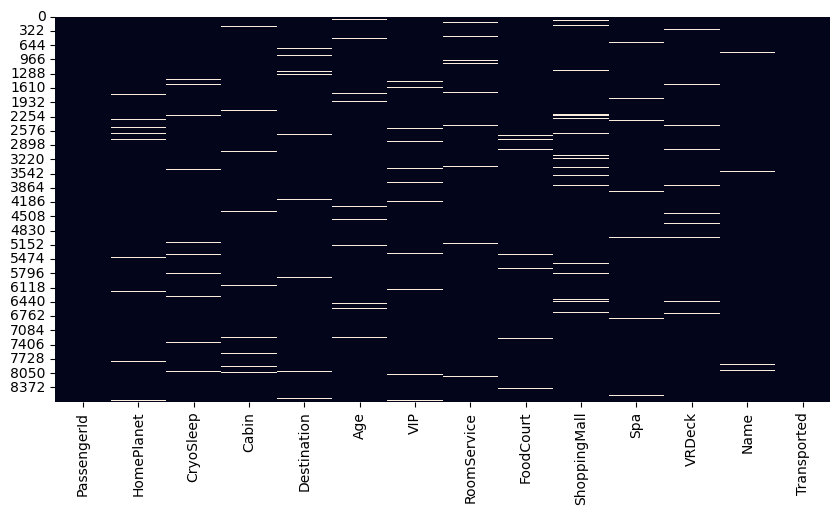

In [285]:
train.isnull().sum().sort_values(ascending=False)    

plt.figure(figsize=(10,5))
sns.heatmap(train.isnull(), cbar=False)
plt.show()

### 1.3 Target Label 확인

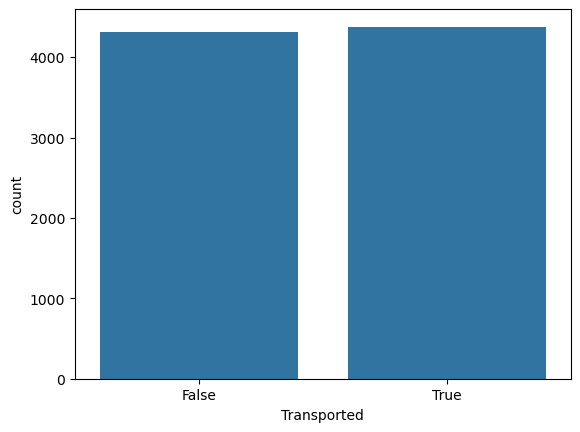

Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64


In [286]:
train['Transported'].value_counts()

sns.countplot(x='Transported', data=train)
plt.show()

print(train['Transported'].value_counts(normalize=True))

In [287]:
print(train.columns)

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='object')


## 2. EDA   


### 2.1 HomePlanet

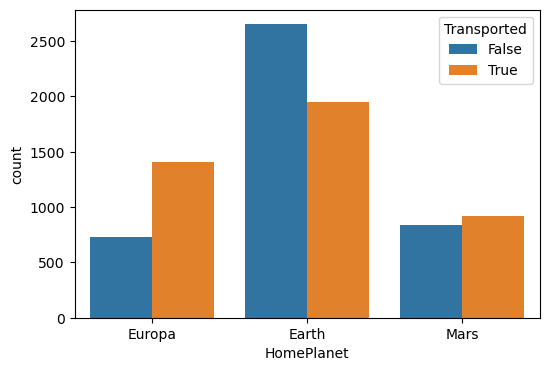

In [288]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='HomePlanet',
    hue='Transported',
    data=train
)

plt.show()

In [289]:
##### Earth, Europa, Mars 순으로 생존자 높음

### 2.2 CryoSleep

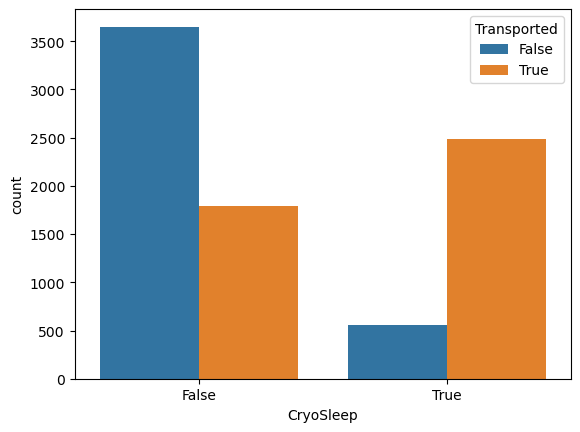

In [290]:
sns.countplot(
    x='CryoSleep',
    hue='Transported',
    data=train
)

plt.show()

In [291]:
pd.crosstab(
    train['CryoSleep'],
    train['Transported'],
    normalize='index'
)

Transported,False,True
CryoSleep,,
False,0.671079,0.328921
True,0.182417,0.817583


CryoSleep 승객은 Transported 비율이 매우 높다.

### 2.3 Destination

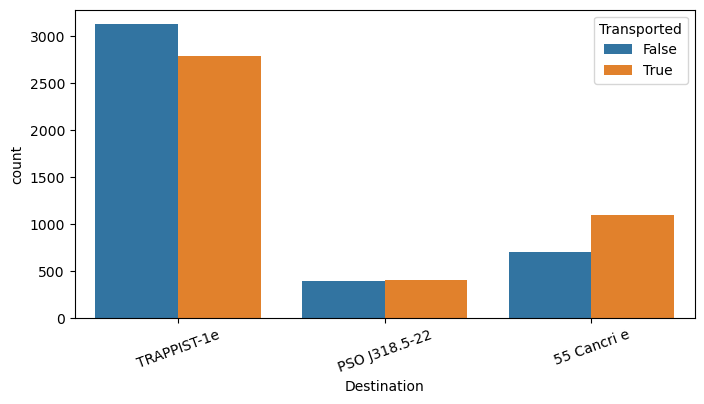

In [292]:
plt.figure(figsize=(8,4))

sns.countplot(
    x='Destination',
    hue='Transported',
    data=train
)

plt.xticks(rotation=20)
plt.show()

TRAPPIST-1e 가 

### 2.4 Age

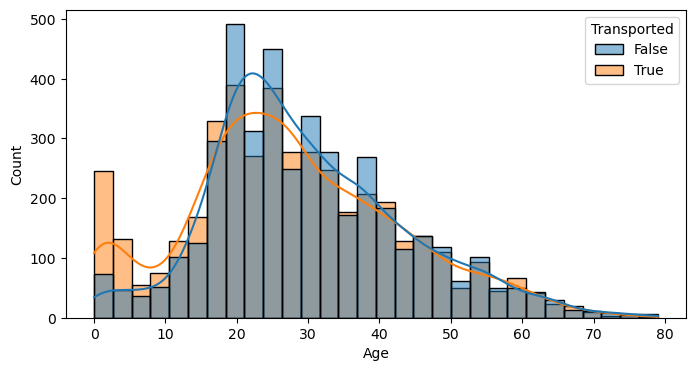

In [293]:
plt.figure(figsize=(8,4))

sns.histplot(
    data=train,
    x='Age',
    hue='Transported',
    kde=True,
    bins=30
)

plt.show()

In [294]:
train['AgeGroup'] = pd.cut(
    train['Age'],
    bins=[0, 12, 18, 30, 50, 80],
    labels=['Child','Teen','Young','Adult','Senior']
)

pd.crosstab(
    train['AgeGroup'],
    train['Transported'],
    normalize='index'
)

Transported,False,True
AgeGroup,,
Child,0.331210,0.668790
Teen,0.462701,0.537299
Young,0.531810,0.468190
Adult,0.520568,0.479432
Senior,0.515604,0.484396


0~12세 아이들이 67퍼센트로 이송되었다.

### 2.5 VIP

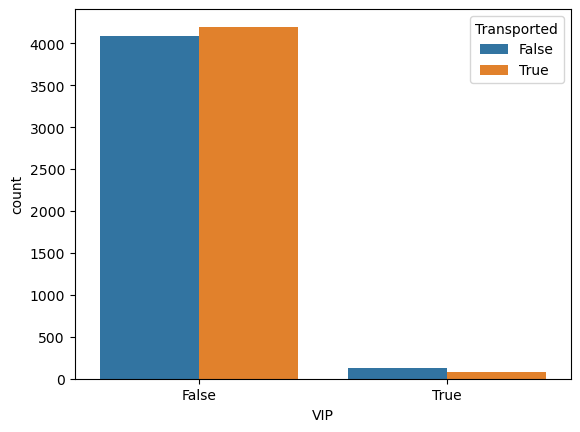

In [295]:
sns.countplot(
    x='VIP',
    hue='Transported',
    data=train
)

plt.show()

VIP는 거의다 이송되지 않음!

### 2.6 Cabin

In [296]:
train[['Deck','CabinNum','Side']] = train['Cabin'].str.split('/', expand=True) ## cabin을 분해
test[['Deck','CabinNum','Side']] = test['Cabin'].str.split('/', expand=True)

Deck

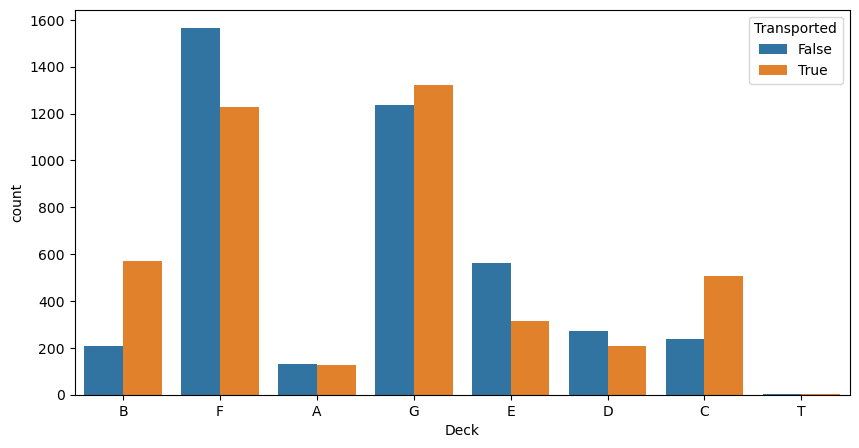

In [297]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Deck',
    hue='Transported',
    data=train
)

plt.show()

Side

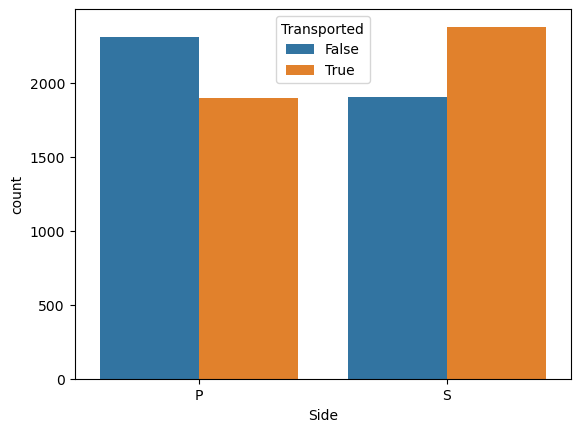

In [298]:
sns.countplot(
    x='Side',
    hue='Transported',
    data=train
)

plt.show()

### 2.7 소비 패턴 분석

In [299]:
spending_cols = [
    'RoomService',       
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck'
]

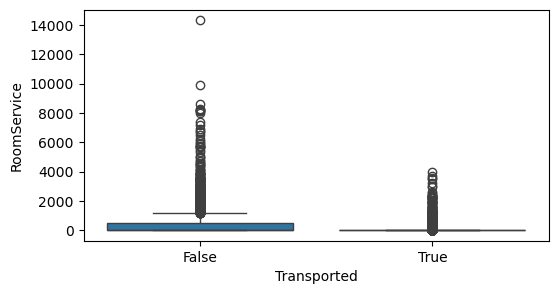

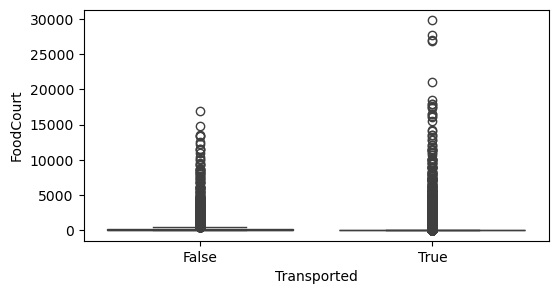

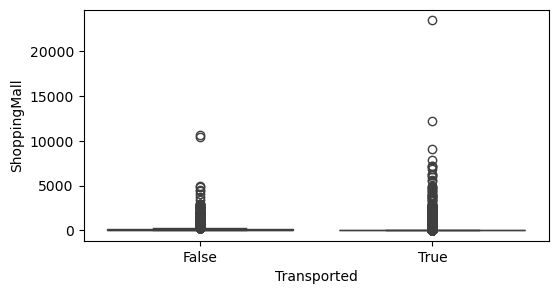

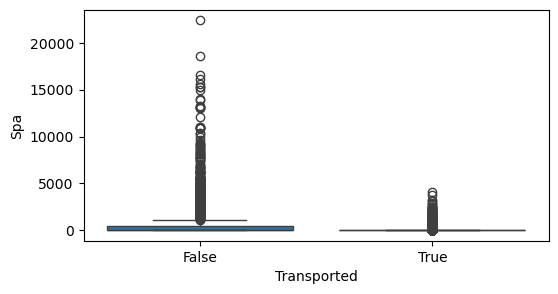

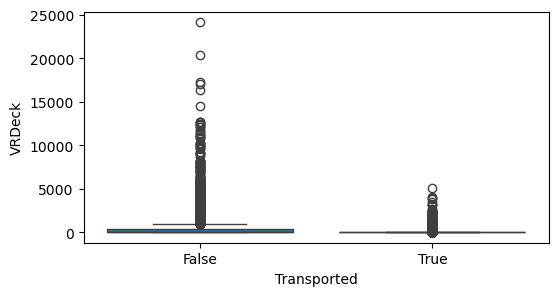

In [300]:
for col in spending_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(
        x='Transported',
        y=col,
        data=train
    )

    plt.show()

동면 여부, 소비패턴(0원 이상)  나이(0~12세)  덱 위치  destination

소비 데이터 전체 (0원 여부) & CryoSleep (동면 여부)

최상위 치트키 변수입니다. 동면 상태이거나 소비가 전혀 없는 승객이 이송될 확률이 압도적으로 높습니다. 피처 엔지니어링 단계에서 TotalSpending(총 지출액) 변수를 만들거나 IsUnseasoned(지출이 0원인지 여부) 같은 바이너리(0 또는 1) 변수를 새로 생성해 주면 모델 성능이 크게 뜁니다.

🥈 Age (나이)

12세 이하 어린이(Child) 승객의 이송률이 독보적으로 높습니다. 모델이 이 나이대를 인지할 수 있도록 나이대를 범주화(Binning)해주는 것이 좋습니다.

🥉 Cabin - Deck & Side (객실 위치)

Deck: B, C 데크가 생존(이송)에 유리했고, F, E 데크가 불리했습니다.

Side: 우현(S)에 묵었던 승객들이 좌현(P) 승객들보다 확실히 많이 이송되었습니다.

🏅 HomePlanet & Destination (출신 및 목적지)

Europa 출신 승객이나 55 Cancri e로 향하던 승객들이 상대적으로 약간 더 높은 이송률을 보였습니다.

## 3. Feature Engineering

### 3.1 Cabin 분해

In [301]:
for df in [train, test]:

    df[['Deck', 'CabinNum', 'Side']] = (
        df['Cabin']
        .str.split('/', expand=True)
    )

    df['CabinNum'] = pd.to_numeric(
        df['CabinNum'],
        errors='coerce'
    )

### 3.2 Group 정보 생성

In [304]:
for df in [train, test]:
# Group 정보
    df['Group'] = df['PassengerId'].str.split('_').str[0]
    
    # 성씨(Surname) 추출
    df['Surname'] = df['Name'].fillna('Unknown').str.split().str[-1]

In [305]:
# GroupSize 및 FamilySize 계산 (Data Leakage 방지를 위해 전체 데이터 기준 계산)
all_groups = pd.concat([train['Group'], test['Group']])
group_counts = all_groups.value_counts()

all_surnames = pd.concat([train['Surname'], test['Surname']])
surname_counts = all_surnames.value_counts()
# Unknown은 가족 크기 계산에서 제외 (혼자 온 것으로 간주하거나 평균 처리 위해 1로 세팅)
surname_counts['Unknown'] = 1

In [306]:
for df in [train,test]:

    df['GroupSize'] = (
        df.groupby('Group')['Group']
        .transform('count')
    )
    df['FamilySize'] = df['Surname'].map(surname_counts)
    df['IsAlone'] = (
        df['GroupSize'] == 1
    ).astype(int)
    

### 3.3 총 소비금액 생성

In [307]:
spending_cols = [
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck'
]


In [308]:
for df in [train, test]:

    df['TotalSpend'] = (
        df[spending_cols]
        .fillna(0)
        .sum(axis=1)
    )
  

In [309]:
for df in [train, test]:
    # [조건 1] 동면(CryoSleep이 True) 중인 사람의 소비 결측치는 무조건 0으로 채우기
    for col in spending_cols:
        df.loc[(df['CryoSleep'] == True) & (df[col].isna()), col] = 0

  # [조건 2] 반대로 돈을 한푼이라도 쓴 사람은 동면(CryoSleep)을 False로 채우기
  
    df.loc[(df['TotalSpend'] > 0) & (df['CryoSleep'].isna()), 'CryoSleep'] = False

### 3.4 결측치 처리

In [310]:
num_cols = [           ## 수치형 데이
    'Age',
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck',
    'CabinNum'
]

for col in num_cols:

    median_val = train[col].median()

    train[col] = train[col].fillna(median_val)
    test[col] = test[col].fillna(median_val)
  

In [311]:
cat_cols = [          ## 범주형 데이터 
    'HomePlanet',
    'CryoSleep',
    'Destination',
    'VIP',
    'Deck',
    'Side'
]

for col in cat_cols:

    mode_val = train[col].mode()[0]

    train[col] = train[col].fillna(mode_val)
    test[col] = test[col].fillna(mode_val)

### 3.5 Age 구간화

In [312]:
# 3. 결측치가 채워진 후 파생 변수 마무리 생성
# ==========================================
for df in [train, test]:
    # 소비 0원 여부
    df['IsZeroSpend'] = (df['TotalSpend'] == 0).astype(int)
    
    # 동면이면서 소비 0원인 찐동면자 변수
    df['NoSpendCryo'] = ((df['TotalSpend'] == 0) & (df['CryoSleep'] == 1)).astype(int)
    
    # 나이 구간화 (결측치가 채워진 후 안전하게 진행)
    df['AgeBand'] = pd.cut(df['Age'], bins=[-1, 12, 18, 30, 50, 100], labels=False)
    
    # Bool -> Int 변환
    df['CryoSleep'] = df['CryoSleep'].astype(int)
    df['VIP'] = df['VIP'].astype(int)

### 3.6 One-Hot Encoding

In [313]:
encode_cols = ['HomePlanet', 'Destination', 'Deck', 'Side']

In [314]:
all_data = pd.concat(
    [train.drop('Transported', axis=1),
     test],
    axis=0
)

In [316]:
all_data = pd.get_dummies(   ## 범주형 변수 인코딩 
    all_data,
    columns=encode_cols, drop_first=True)


### 3.7 불필요 컬럼 제거

In [317]:
drop_cols = [
    'PassengerId',
    'Cabin',
    'Name',
    'Group',
    'CabinNum',
    'Surname'
]

all_data.drop(
    columns=drop_cols,
    inplace=True
)

In [318]:
for df in [train, test]:

    df['NoSpendCryo'] = (
        (df['TotalSpend'] == 0)
        & (df['CryoSleep'] == 1)
    ).astype(int)

In [319]:
## ++성씨 활용

In [320]:
for df in [train, test]:

    df['Surname'] = (
        df['Name']
        .fillna('Unknown')
        .str.split()
        .str[-1]
    )

## 4. 모델 학습

### 4.1 Train / Validation 분리

In [321]:
X = all_data[:len(train)]      ## train, test 분리
X_test = all_data[len(train):]

y = train['Transported']

In [322]:
from sklearn.model_selection import train_test_split   

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 4.2 Model Generation and Prediction

#### 4.2.1  LightGBM

In [323]:
!pip install lightgbm

In [326]:
from lightgbm import LGBMClassifier    
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold

In [335]:
# 1. 5-Fold 교차 검증 세팅
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# 예측 결과를 저장할 배열 초기화
oof_preds = np.zeros(len(X))  # Validation 평가용
test_preds = np.zeros(len(X_test))  # Test 최종 제출용 (확률 저장)

# 피처 중요도를 기록할 배열
feature_importances = np.zeros(X.columns.shape[0])



In [336]:
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
    X_valid_fold, y_valid_fold = X.iloc[valid_idx], y.iloc[valid_idx]

    lgbm = LGBMClassifier(
        n_estimators=1000,       # 트리 개수를 늘리는 대신
        learning_rate=0.01,
        max_depth=7,            # 깊이를 살짝 줄여 과적합 방지
        num_leaves=31,          # 트리 노드 수 제한
        subsample=0.8,          # 데이터 샘플링 (Row)
        colsample_bytree=0.8,   # 피처 샘플링 (Column)
        random_state=42,
        min_child_samples=20,
        verbose=-1              # 불필요한 경고문 출력 방지
    )
    
    lgbm.fit(
    X_train_fold, y_train_fold,
        eval_set=[(X_valid_fold, y_valid_fold)],
        callbacks=[] # 필요시 여기에 early_stopping 추가 가능
    )

    # Validation 예측 (★ 변수명을 lgbm으로 통일)
    val_preds = lgbm.predict_proba(X_valid_fold)[:, 1]
    oof_preds[valid_idx] = val_preds
    
    # Test 예측
    test_preds += lgbm.predict_proba(X_test)[:, 1] / n_splits
    
    # 피처 중요도 누적
    feature_importances += lgbm.feature_importances_ / n_splits
    
    # 결과 출력
    fold_score = accuracy_score(y_valid_fold, (val_preds > 0.5).astype(int))
    print(f"Fold {fold+1} Accuracy : {fold_score:.4f}")

Fold 1 Accuracy : 0.8143
Fold 2 Accuracy : 0.7941
Fold 3 Accuracy : 0.8131
Fold 4 Accuracy : 0.8182
Fold 5 Accuracy : 0.7906


In [337]:
total_oof_score = accuracy_score(y, (oof_preds > 0.5).astype(int))
print("\n==========================================")
print(f"Total OOF CV Accuracy : {total_oof_score:.4f}")
print("==========================================")


Total OOF CV Accuracy : 0.8061


#### 4.2.2 Confusion Matrix

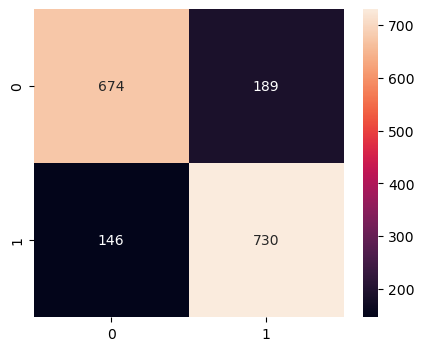

In [338]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_valid,
    pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.show()

## 4.3 Feature Importance

In [339]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lgbm.feature_importances_
})

In [340]:
importance = (
    importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

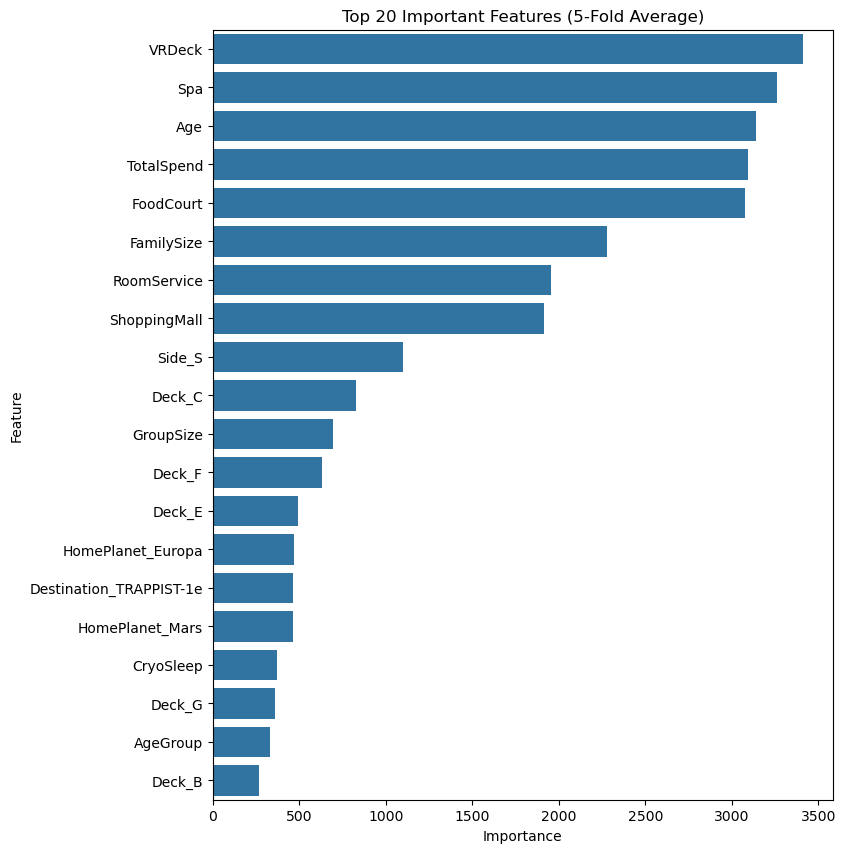

In [341]:
plt.figure(figsize=(8, 10))
sns.barplot(data=importance.head(20), x='Importance', y='Feature')
plt.title('Top 20 Important Features (5-Fold Average)')
plt.show()

### 4.4 Prediction on Test Data

In [342]:
# (5개 모델의 평균 확률이 0.5보다 크면 True, 작으면 False)
final_pred_bool = (test_preds > 0.5).astype(bool)

### 4.5 Submission File Generation

In [343]:
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': final_pred_bool
})

submission.to_csv('submission10.csv', index=False)
print("제출 파일이 성공적으로 저장되었습니다!")
submission.head()

제출 파일이 성공적으로 저장되었습니다!


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


![](./6.png) 